In [63]:
import glob
import pickle
from scene_description import SceneDescription
import shutil, os
from room_type import RoomType

def process_scene_files(room):
    pkl_store = "experiment_data/test_LLAMA/" + room + "/*.pkl"

    pkl_files = glob.glob(pkl_store) # files showing gemma scenes
    #scene_files2 = glob.glob(pkl_store2)

    results = []
    for test_f in pkl_files:
        f = open(test_f,'rb')
        test_res = pickle.load(f)

        #print(f)
        #print(test_res)
        results.extend(test_res)

    return results

# Function to convert result dictionaries to DataFrame
def convert_results_to_df(results_list):
    """Convert a list of result dictionaries to a pandas DataFrame."""
    room_type_fx_results = []
    for item in results_list:
        #print(item["expected_room"].value)
        if (item["object_to_find"] in ["tea kettle", "food processor", "stand mixer", "rolling pin", "baking sheet"]):
            room_type_fx_results.append(item)
    return pd.DataFrame(room_type_fx_results)
    #return pd.DataFrame(results_list)

k = process_scene_files("Kitchen")
#print(len(k))
b = process_scene_files("Bathroom")
#print(len(b))
l = process_scene_files("Living Room")
#print(len(l))
be = process_scene_files("Bedroom")
#print(len(be))
all_results = k
all_results.extend(b)
all_results.extend(l)
all_results.extend(be)
print(len(all_results))
#print(all_results[0:3])

# Process data
df = convert_results_to_df(all_results)
#print(df)
#room_success = df.groupby(['expected_room', 'selected_room']).size().unstack().fillna(0)
#room_success = df.groupby(['selected_room'])
#print(room_success.size())
#room_success = room_success.div(room_success.sum(axis=1), axis=0) * 100  # Convert to percentages

10000


/tmp/ipykernel_234361/1861982501.py:267: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  success_rate = df.groupby('expected_room').apply(


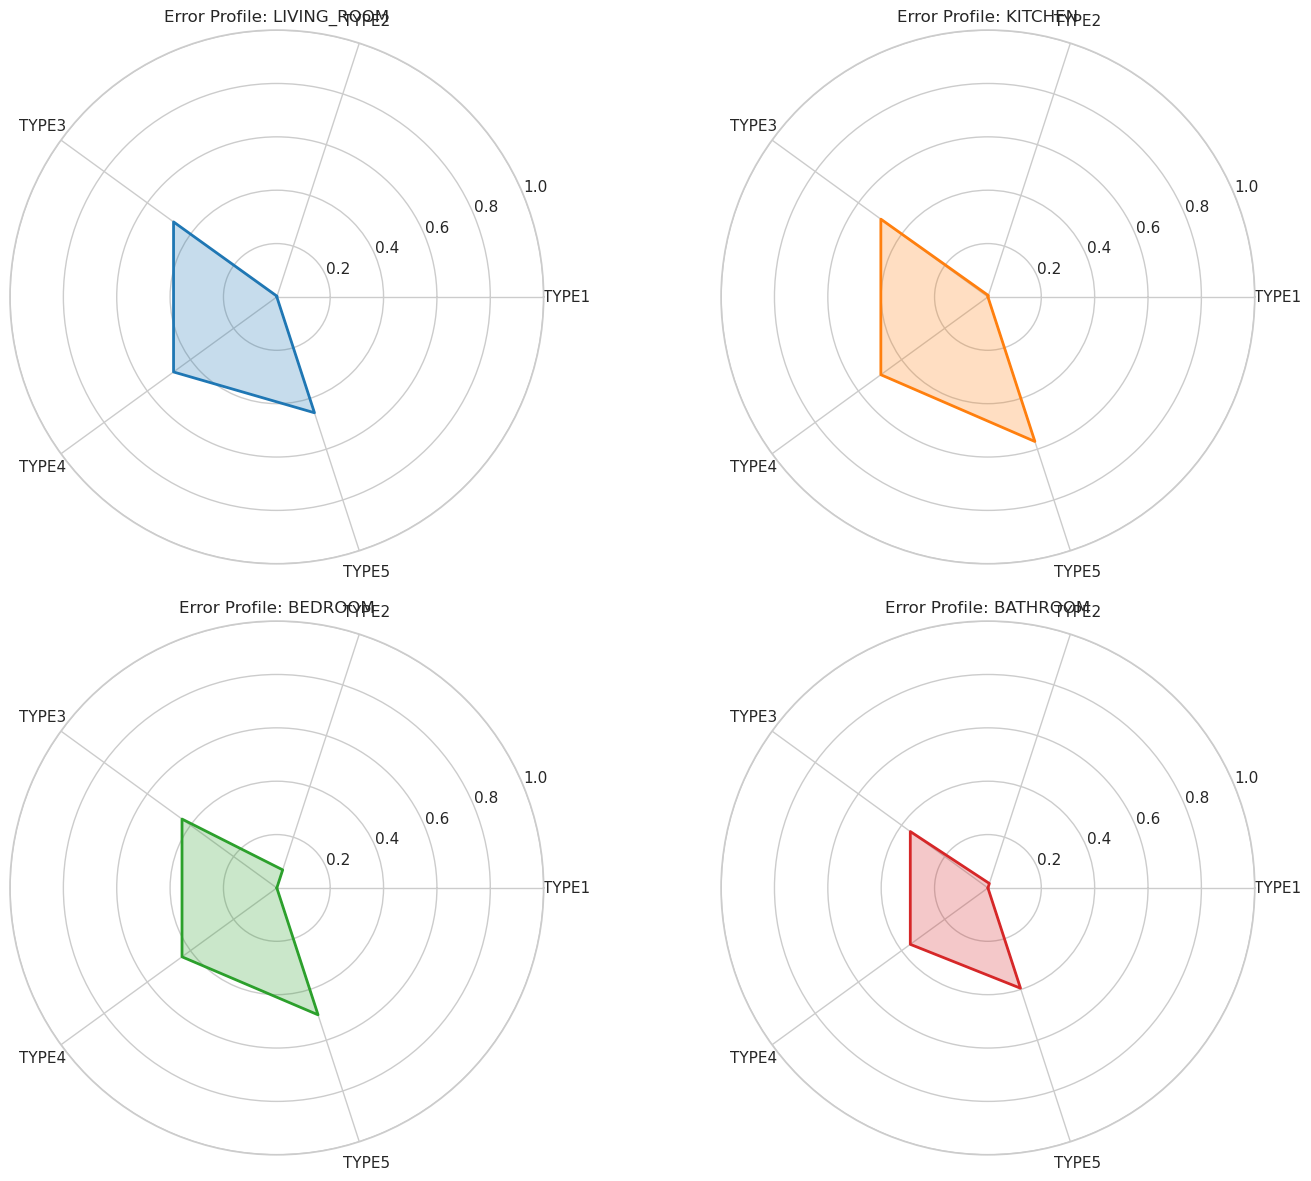

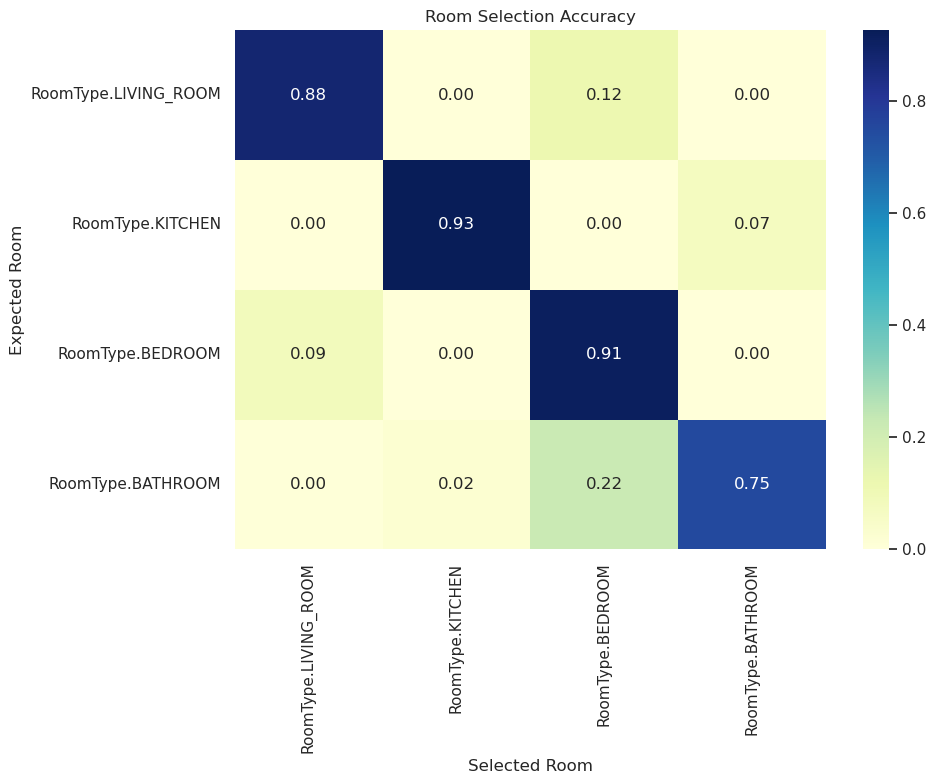

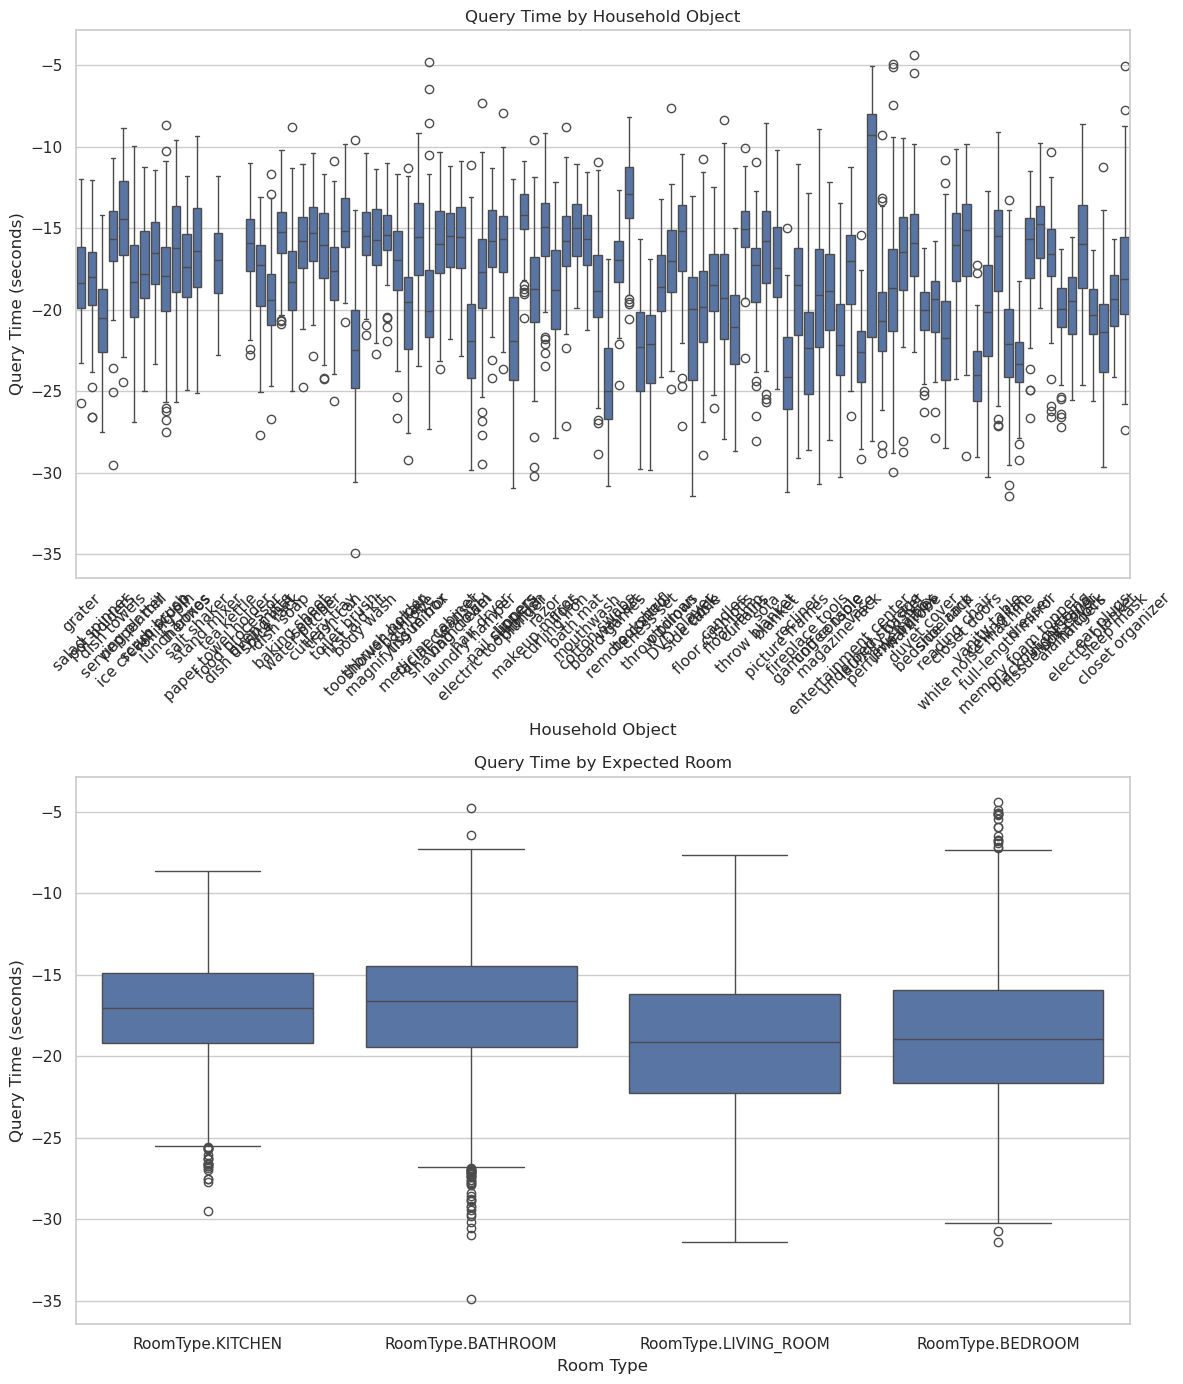

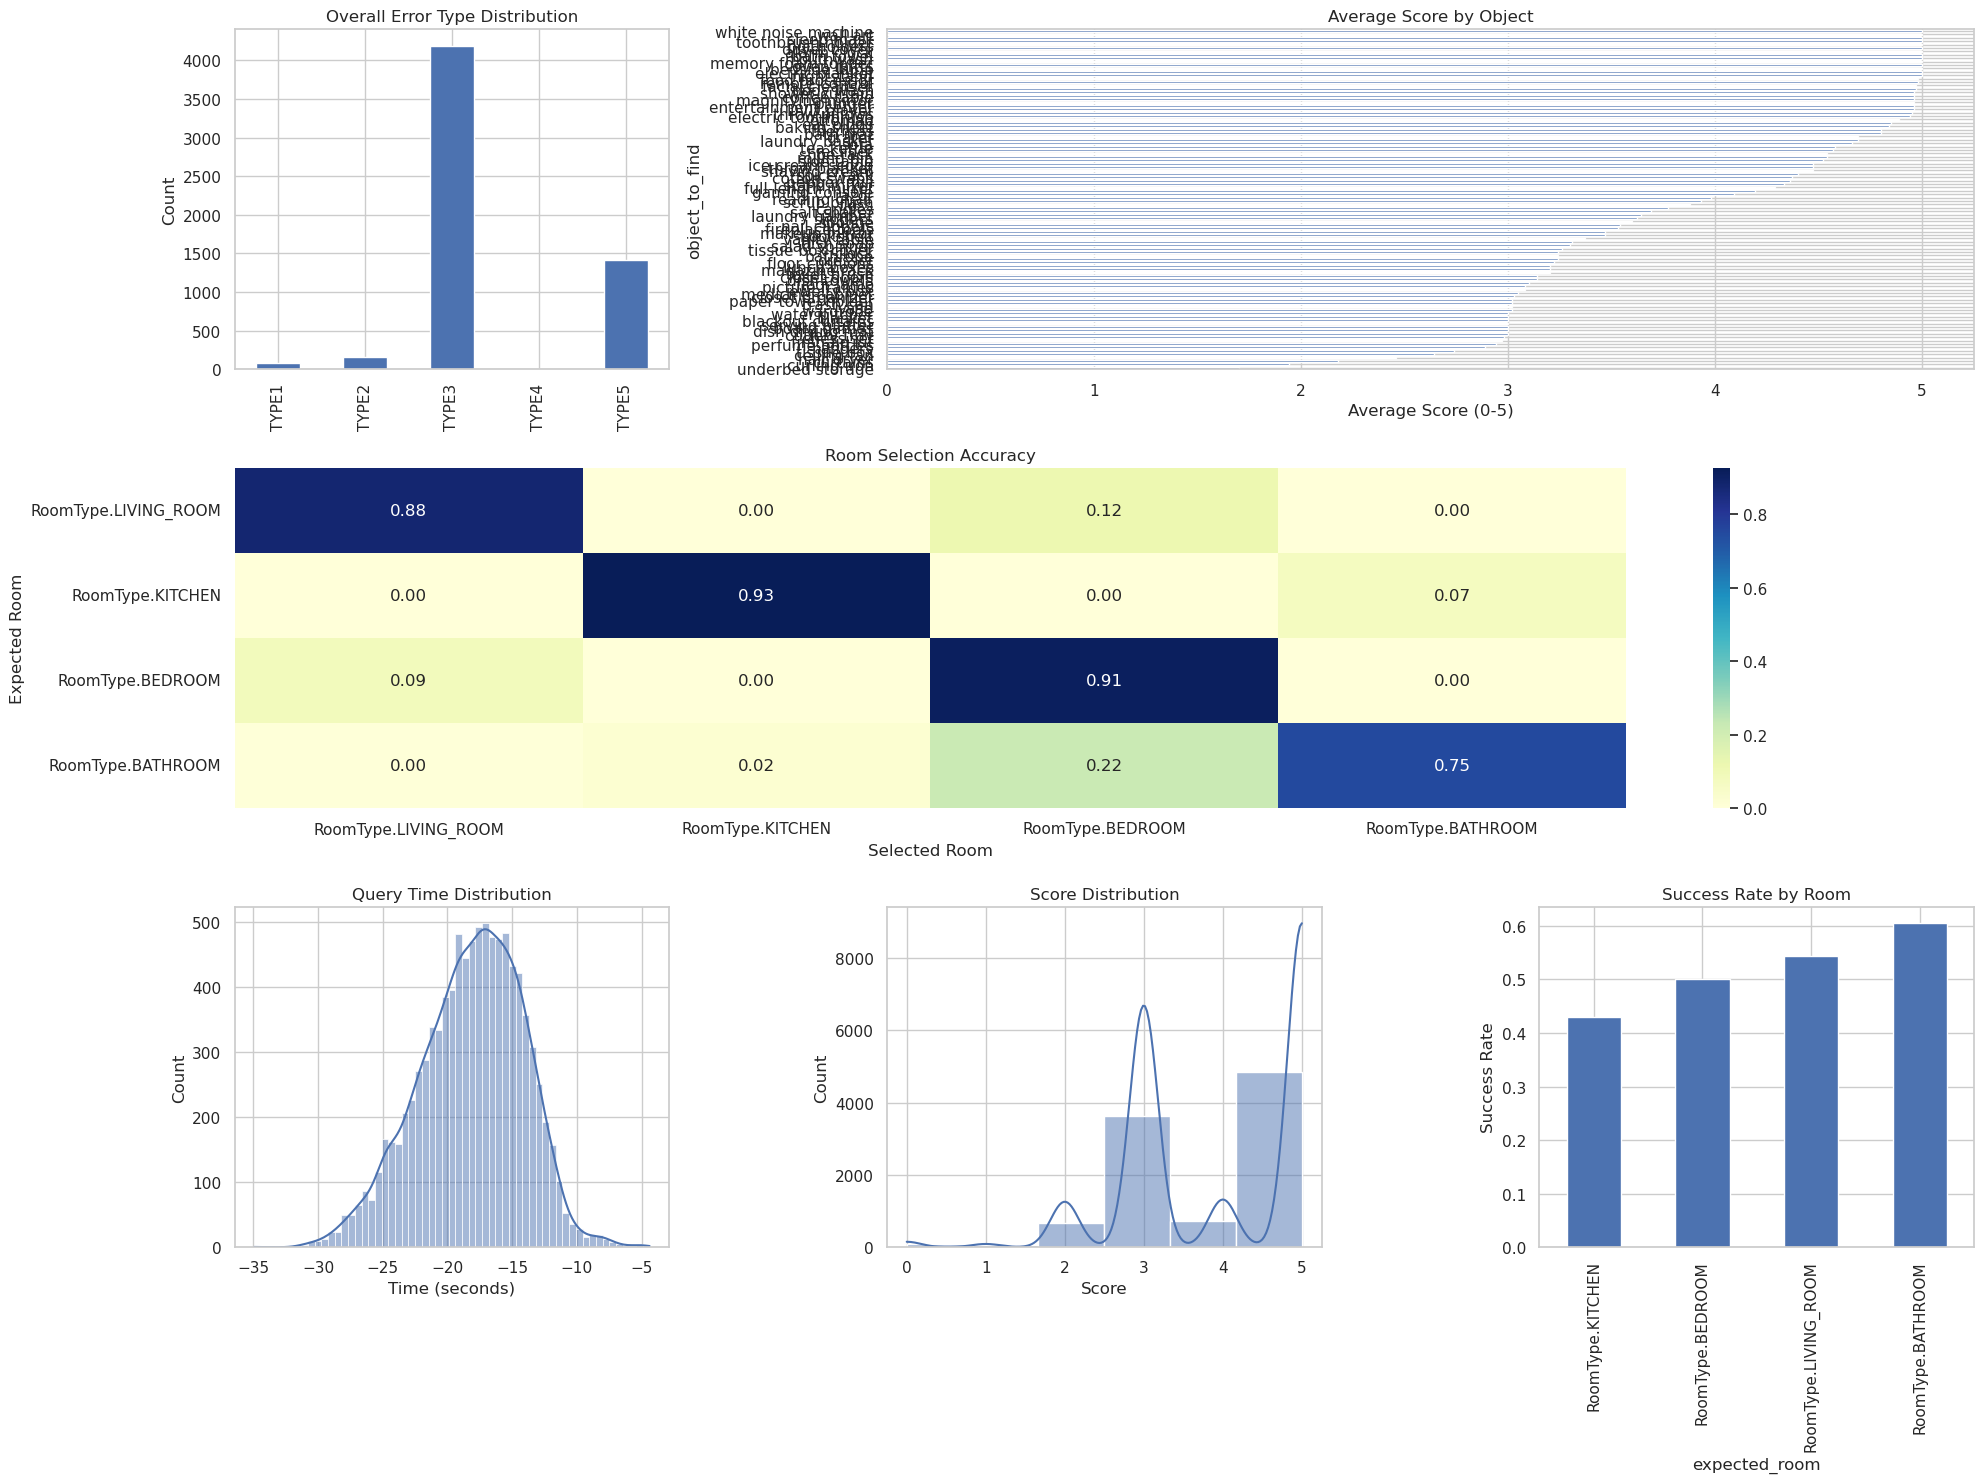

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Polygon
from room_type import RoomType

# Function to convert result dictionaries to DataFrame
def convert_results_to_df_orig(results_list):
    """Convert a list of result dictionaries to a pandas DataFrame."""
    df = pd.DataFrame(results_list)
    
    # Convert string representation of RoomType to actual enum objects if needed
    for col in ['expected_room', 'selected_room', 'room_where_selected_object_is', 'path_end_point_room']:
        if col in df.columns:
            if df[col].empty:
                continue
                
            if isinstance(df[col].iloc[0], str):
                try:
                    df[col] = df[col].apply(lambda x: getattr(RoomType, x) if isinstance(x, str) else x)
                except (AttributeError, TypeError):
                    # Keep as string if conversion fails
                    pass
    
    return df

# Function to convert result dictionaries to DataFrame
def convert_results_to_df(results_list):
    """Convert a list of result dictionaries to a pandas DataFrame."""
    room_type_fx_results = []
    for item in results_list:
        #print(item["expected_room"].value)
        if (item["object_to_find"] in [#"serving platter"
            "tea kettle", "food processor", "stand mixer", "rolling pin", "baking sheet",
            #"pot holders", "oven mitts", "dish towels", "spice rack", "salt shaker",
            #"pepper mill", "cutlery tray", "serving platter", "salad spinner", "ice cream scoop",
            #"grater", "thermos", "lunch boxes", "water pitcher", "paper towel holder",
            #"trash can", "dish soap", "sponge", "scrub brush", "dish drying mat"
        ]):
            #room_type_fx_results.append(item)
            pass
        room_type_fx_results.append(item)
    return pd.DataFrame(room_type_fx_results)
    #return pd.DataFrame(results_list)

# 1. Error Type Distribution by Room Type
def plot_error_types_by_room(all_results):
    """Create a grouped bar chart of error types by room."""
    # Prepare the data
    df = convert_results_to_df(all_results)
    
    # Calculate error types based on your scoring logic
    df['TYPE1'] = (df['selected_room'] == RoomType.NOT_CLASSIFIED).astype(int)
    df['TYPE2'] = ((df['selected_object_name'] == '') | (df['selected_object_name'].isna())).astype(int)
    df['TYPE3'] = ((df['selected_room'] != df['room_where_selected_object_is']) & 
                   (df['selected_room'] != RoomType.NOT_CLASSIFIED)).astype(int)
    df['TYPE4'] = ((df['selected_room'] != df['path_end_point_room']) & 
                   (df['selected_room'] != RoomType.NOT_CLASSIFIED)).astype(int)
    df['TYPE5'] = ((df['expected_room'] != df['path_end_point_room']) & 
                   (df['path_end_point_room'] != RoomType.NOT_CLASSIFIED)).astype(int)
    
    # Group by expected room and calculate error frequencies
    error_by_room = df.groupby('expected_room')[['TYPE1', 'TYPE2', 'TYPE3', 'TYPE4', 'TYPE5']].mean()
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    error_by_room.plot(kind='bar', ax=ax)
    plt.title('Error Type Distribution by Expected Room')
    plt.xlabel('Room Type')
    plt.ylabel('Error Frequency')
    plt.legend(title='Error Types')
    plt.tight_layout()
    
    return fig

# 2. Radar Plot for Error Types by Room
def plot_radar_by_room(all_results):
    """Create radar plots for error types by room."""
    df = convert_results_to_df(all_results)
    
    # Calculate error types
    df['TYPE1'] = (df['selected_room'] == RoomType.NOT_CLASSIFIED).astype(int)
    df['TYPE2'] = ((df['selected_object_name'] == '') | (df['selected_object_name'].isna())).astype(int)
    df['TYPE3'] = ((df['selected_room'] != df['room_where_selected_object_is']) & 
                   (df['selected_room'] != RoomType.NOT_CLASSIFIED)).astype(int)
    df['TYPE4'] = ((df['selected_room'] != df['path_end_point_room']) & 
                   (df['selected_room'] != RoomType.NOT_CLASSIFIED)).astype(int)
    df['TYPE5'] = ((df['expected_room'] != df['path_end_point_room']) & 
                   (df['path_end_point_room'] != RoomType.NOT_CLASSIFIED)).astype(int)
    
    # Group by expected room
    error_by_room = df.groupby('expected_room')[['TYPE1', 'TYPE2', 'TYPE3', 'TYPE4', 'TYPE5']].mean()
    
    # Create a figure with subplots for each room
    fig, axes = plt.subplots(2, 2, figsize=(15, 12), subplot_kw=dict(polar=True))
    axes = axes.flatten()
    
    # Categories for radar chart (error types)
    categories = ['TYPE1', 'TYPE2', 'TYPE3', 'TYPE4', 'TYPE5']
    N = len(categories)
    
    # Angles for radar chart
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop
    
    # Room colors
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    # Valid room types (excluding NOT_KNOWN and NOT_CLASSIFIED)
    valid_rooms = [room for room in RoomType if room.value <= 4]
    
    for i, room in enumerate(valid_rooms):
        if room in error_by_room.index:
            ax = axes[i]
            values = error_by_room.loc[room, categories].tolist()
            values += values[:1]  # Close the loop
            
            ax.plot(angles, values, linewidth=2, color=colors[i])
            ax.fill(angles, values, color=colors[i], alpha=0.25)
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(categories)
            ax.set_title(f'Error Profile: {room.name}')
            ax.set_ylim(0, 1)
            
    plt.tight_layout()
    
    return fig

# 3. Score Distribution by Object
def plot_score_distribution(all_results):
    """Create a violin plot showing score distribution by object."""
    df = convert_results_to_df(all_results)
    
    plt.figure(figsize=(14, 8))
    sns.set(style = 'whitegrid') 
    sns.violinplot(x='object_to_find', y='score_for_this_run', data=df, cut=0, bw_method=0.2, inner='point')
    plt.title('Score Distribution by Household Object')
    plt.xlabel('Household Object')
    plt.ylabel('Score (0-5)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return plt.gcf()

def plot_score_distribution_1(all_results):
    df = convert_results_to_df(all_results)
    plt.figure(figsize=(14, 8))
    sns.violinplot(
        x='object_to_find', 
        y='score_for_this_run', 
        data=df,
        color='lightgray',
        cut=0
    )
    sns.swarmplot(  # Overlay actual points
        x='object_to_find', 
        y='score_for_this_run', 
        data=df,
        color='black',
        size=3
    )
    plt.title('Hybrid Violin-Swarm Plot')
    plt.xticks(rotation=45)

    return plt.gcf()

# 4. Room Selection Accuracy
def plot_room_selection_accuracy(all_results):
    """Create a heatmap showing room selection accuracy."""
    df = convert_results_to_df(all_results)
    
    # Create contingency table of expected vs selected rooms
    room_contingency = pd.crosstab(
        df['expected_room'], 
        df['selected_room'], 
        normalize='index'
    )
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(room_contingency, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title('Room Selection Accuracy')
    plt.xlabel('Selected Room')
    plt.ylabel('Expected Room')
    plt.tight_layout()
    
    return plt.gcf()

# 5. Query Time Analysis
def plot_query_time_analysis(all_results):
    """Create box plots for query time by object and room."""
    df = convert_results_to_df(all_results)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))
    
    # Query time by object
    sns.boxplot(x='object_to_find', y='qry_time', data=df, ax=ax1)
    ax1.set_title('Query Time by Household Object')
    ax1.set_xlabel('Household Object')
    ax1.set_ylabel('Query Time (seconds)')
    ax1.tick_params(axis='x', rotation=45)
    
    # Query time by expected room
    sns.boxplot(x='expected_room', y='qry_time', data=df, ax=ax2)
    ax2.set_title('Query Time by Expected Room')
    ax2.set_xlabel('Room Type')
    ax2.set_ylabel('Query Time (seconds)')
    
    plt.tight_layout()
    
    return fig

# 6. Overall Performance Dashboard
def create_performance_dashboard(all_results):
    """Create a comprehensive dashboard with key metrics."""
    df = convert_results_to_df(all_results)
    
    # Calculate error types
    df['TYPE1'] = (df['selected_room'].isna()).astype(int)
    df['TYPE2'] = (df['selected_room'].notna() & df['selected_object_name'].isna()).astype(int)
    df['TYPE3'] = ((df['selected_object_name'].notna()) & (df['selected_room'] != df['room_where_selected_object_is'])).astype(int)
    df['TYPE4'] = ((df['room_where_selected_object_is'].notna()) & (df['room_where_selected_object_is'] != df['path_end_point_room'])).astype(int)
    df['TYPE5'] = (df['expected_room'] != df['selected_room']).astype(int)
    
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Overall error distribution
    ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=1)
    error_counts = df[['TYPE1', 'TYPE2', 'TYPE3', 'TYPE4', 'TYPE5']].sum()
    error_counts.plot(kind='bar', ax=ax1)
    ax1.set_title('Overall Error Type Distribution')
    ax1.set_ylabel('Count')
    
    # 2. Average score by object
    ax2 = plt.subplot2grid((3, 3), (0, 1), colspan=2)
    avg_scores = df.groupby('object_to_find')['score_for_this_run'].mean().sort_values()
    avg_scores.plot(kind='barh', ax=ax2)
    ax2.set_title('Average Score by Object')
    ax2.set_xlabel('Average Score (0-5)')
    
    # 3. Room selection confusion matrix
    ax3 = plt.subplot2grid((3, 3), (1, 0), colspan=3)
    room_contingency = pd.crosstab(
        df['expected_room'], 
        df['selected_room'], 
        normalize='index'
    )
    sns.heatmap(room_contingency, annot=True, cmap='YlGnBu', fmt='.2f', ax=ax3)
    ax3.set_title('Room Selection Accuracy')
    ax3.set_xlabel('Selected Room')
    ax3.set_ylabel('Expected Room')
    
    # 4. Query time distribution
    ax4 = plt.subplot2grid((3, 3), (2, 0), colspan=1)
    sns.histplot(df['qry_time'], kde=True, ax=ax4)
    ax4.set_title('Query Time Distribution')
    ax4.set_xlabel('Time (seconds)')
    
    # 5. Score distribution
    ax5 = plt.subplot2grid((3, 3), (2, 1), colspan=1)
    sns.histplot(df['score_for_this_run'], kde=True, bins=6, ax=ax5)
    ax5.set_title('Score Distribution')
    ax5.set_xlabel('Score')
    
    # 6. Success rate by room
    ax6 = plt.subplot2grid((3, 3), (2, 2), colspan=1)
    success_rate = df.groupby('expected_room').apply(
        lambda x: (x['expected_room'] == x['path_end_point_room']).mean()
    ).sort_values()
    success_rate.plot(kind='bar', ax=ax6)
    ax6.set_title('Success Rate by Room')
    ax6.set_ylabel('Success Rate')
    
    plt.tight_layout()
    
    return fig

# Example usage:
if __name__ == "__main__":
    # Generate sample data for testing
    def generate_sample_data(n_samples=20, n_objects=5):
        """Generate sample data for demonstration."""
        objects = [f"Object_{i}" for i in range(1, n_objects + 1)]
        
        all_results = []
        
        for obj in objects:
            # Assign a most likely room for this object
            expected_room = np.random.choice([
                RoomType.LIVING_ROOM, 
                RoomType.KITCHEN, 
                RoomType.BEDROOM, 
                RoomType.BATHROOM
            ])
            
            for _ in range(n_samples):
                # Simulate different types of errors
                if np.random.random() < 0.8:
                    selected_room = expected_room
                else:
                    if np.random.random() < 0.5:
                        rooms = [r for r in [RoomType.LIVING_ROOM, RoomType.KITCHEN, 
                                            RoomType.BEDROOM, RoomType.BATHROOM] 
                                if r != expected_room]
                        selected_room = np.random.choice(rooms)
                    else:
                        selected_room = RoomType.NOT_CLASSIFIED
                
                # Object selection
                if np.random.random() < 0.9:
                    object_name = f"Nearby_Item_{np.random.randint(1, 10)}"
                    if np.random.random() < 0.85:
                        room_where_obj_is = selected_room if selected_room != RoomType.NOT_CLASSIFIED else expected_room
                    else:
                        rooms = [r for r in [RoomType.LIVING_ROOM, RoomType.KITCHEN, 
                                            RoomType.BEDROOM, RoomType.BATHROOM]]
                        room_where_obj_is = np.random.choice(rooms)
                else:
                    object_name = ""
                    room_where_obj_is = RoomType.NOT_CLASSIFIED
                
                # Path planning
                if np.random.random() < 0.9:
                    end_point_room = room_where_obj_is
                else:
                    rooms = [r for r in [RoomType.LIVING_ROOM, RoomType.KITCHEN, 
                                        RoomType.BEDROOM, RoomType.BATHROOM]]
                    end_point_room = np.random.choice(rooms)
                
                # Calculate score based on error types
                score = 5
                
                # TYPE1: No room selected
                if selected_room == RoomType.NOT_CLASSIFIED:
                    score -= 1
                
                # TYPE2: No object selected
                if not object_name:
                    score -= 1
                
                # TYPE3: Object in different room
                if selected_room != room_where_obj_is and selected_room != RoomType.NOT_CLASSIFIED:
                    score -= 1
                
                # TYPE4: Path led to different room
                if selected_room != end_point_room and selected_room != RoomType.NOT_CLASSIFIED:
                    score -= 1
                
                # TYPE5: Ended up in unexpected room
                if expected_room != end_point_room and end_point_room != RoomType.NOT_CLASSIFIED:
                    score -= 1
                
                # Query time simulation (between 0.5 and 3 seconds)
                qry_time = np.random.uniform(0.5, 3.0)
                
                result = {
                    "object_to_find": obj,
                    "expected_room": expected_room,
                    "selected_room": selected_room,
                    "selected_object_name": object_name,
                    "room_where_selected_object_is": room_where_obj_is,
                    "path_end_point_room": end_point_room,
                    "score_for_this_run": score,
                    "qry_time": qry_time,
                    "full_text_room": f"Sample room selection text for {obj}",
                    "full_text_obj": f"Sample object selection text for {obj}"
                }
                
                all_results.append(result)
        
        return all_results
    
    # Generate sample data
    sample_data = generate_sample_data(n_samples=20, n_objects=5)
    #print(sample_data)

    sample_data = all_results
    
    # Create and display visualizations
    radar_fig = plot_radar_by_room(sample_data)
    plt.figure(radar_fig.number)
    plt.savefig("radar_plot.png")
    
#    score_fig = plot_score_distribution(sample_data)
#    plt.figure(score_fig.number)
#    plt.savefig("score_distribution.png")
    
    accuracy_fig = plot_room_selection_accuracy(sample_data)
    plt.figure(accuracy_fig.number)
    plt.savefig("room_accuracy.png")
    
    time_fig = plot_query_time_analysis(sample_data)
    plt.figure(time_fig.number)
    plt.savefig("query_time.png")
    
    dashboard_fig = create_performance_dashboard(sample_data)
    plt.figure(dashboard_fig.number)
    plt.savefig("dashboard.png")
    
    plt.show()